# 06. DECam Streak Photometry
Written by Kiyoaki Okudaira and Meredith Rawls<br>
*University of Washington / IAU CPS SatHub<br>
(kiyoaki@uw.edu or okudaira.kiyoaki.528@s.kyushu-u.ac.jp)<br>
<br>
This code is written for ASTR 499 undergraduate research with Dr. Meredith.<br>
A notebook to photometry satellite streak and query the SatChecker Field Of View (FOV) service.<br>
<br>
**History**<br>
coding 2026-02-21 : 1st coding<br>
update 2026-05-31 : enhance readability

### Import and initial settings
**Standard libraries**

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from os import path
import pickle
import json

from scipy.stats import sigmaclip
import requests

from IPython.display import clear_output

import astropy.units as u
from astropy.time import Time
from astropy.coordinates import EarthLocation
from astropy.io import fits
from astropy.table import Table
from astropy.table import MaskedColumn
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from photutils.aperture import RectangularAperture, aperture_photometry
from astropy.coordinates import AltAz

from tqdm.notebook import tqdm

**Satphotometry library**

In [2]:
import satphotometry as sp

**Import file settings**

In [3]:
# project directory
PATH_project = '/astro/store/shire/kiyoaki/ASTR499/'

PATH_input   = PATH_project + 'input/'
PATH_output  = PATH_project + 'output/'

PATH_image   = PATH_input  + 'fits_data/'
PATH_session = PATH_output + 'session/'

# ORIGINAL streak list from Alex
fname_streak_list = 'streaks_augmented_20230817_poster.csv'
PATH_streak_list  = fname_streak_list + 'decam_streak_list/' + fname_streak_list

In [4]:
# image_path = "/astro/store/shire/kiyoaki/ASTR499/input/fits_data/" # Directory where DECam images are saved | str
# output_path = "/astro/store/shire/kiyoaki/ASTR499/output/"
# group_num = 1
# row_num   = 1

**Process method setting**

In [ ]:
paralell_process = True
if paralell_process:
    from concurrent.futures import ThreadPoolExecutor, as_completed

### Load Streak Dataset
Dataset is grouped by EXPNUM because if the EXPNUM is the same, the request to satchecker is the same．

In [209]:
with open(PATH_session+path.splitext(path.basename(fname_streak_list))[0]+'_05_identify.pkl', 'rb') as f:
    streak_table = pickle.load(f)
streak_table = streak_table.group_by("expnum")
output = []

mag_arcsec_list = [None] * len(streak_table)

### Photometry
**Photometry (single processing)**

In [54]:
if paralell_process is False:
    for row in tqdm(streak_table[~(np.isfinite(mag_zen))][0:1]):
        basename = path.basename(row["archive_filename"])
        md5sum = row["md5sum"]
        expnum = row["expnum"]
        ccdnum = row["ccdnum"]
        streak_ID = row["streakID"]
        idx = np.where(streak_table["streakID"] == streak_ID)[0][0]

        save_path = PATH_image + path.splitext(path.splitext(basename)[0])[0] + "_CCD_{0}".format(ccdnum) + path.splitext(path.splitext(basename)[0])[1] + path.splitext(basename)[1]

        hdu = fits.open(save_path)
        main_header = hdu[0].header
        ccd_header = hdu[1].header
        ccd_data = hdu[1].data
        ccd_wcs = WCS(ccd_header)

        ccd_data = fits.getdata(save_path,1)
        rotated_img,r_matrix,r_pararell = sp.imgrotation.rotate_image(ccd_data, row["rt_angle"], row["initial_streak_coord"], True, 100, True)

        streak_x_min = row["streak_x_min"]
        streak_x_max = row["streak_x_max"]
        streak_y     = row["streak_y"]
        sigma_mean   = row["streak_sigma"]

        # rotation
        def _inv_rot(x, y, r_matrix, r_pararell, wcs):
            p = np.array([x, y], dtype=float)
            src_xy = r_matrix @ (p - r_pararell)
            src_radec = wcs.pixel_to_world(src_xy[0], src_xy[1])
            return src_xy,src_radec

        streak_sc_src_xy,streak_sc_radec = _inv_rot(streak_x_min, streak_y, r_matrix, r_pararell, ccd_wcs)
        streak_ec_src_xy,streak_ec_radec = _inv_rot(streak_x_max, streak_y, r_matrix, r_pararell, ccd_wcs)

        streak_s1_src_xy,streak_s1_radec = _inv_rot(streak_x_min, streak_y-3*sigma_mean, r_matrix, r_pararell, ccd_wcs)
        streak_s2_src_xy,streak_s2_radec = _inv_rot(streak_x_min, streak_y+3*sigma_mean, r_matrix, r_pararell, ccd_wcs)
        streak_e1_src_xy,streak_e1_radec = _inv_rot(streak_x_max, streak_y-3*sigma_mean, r_matrix, r_pararell, ccd_wcs)
        streak_e2_src_xy,streak_e2_radec = _inv_rot(streak_x_max, streak_y+3*sigma_mean, r_matrix, r_pararell, ccd_wcs)

        # image plot
        # quad for plot
        quad_x_src = [
            len(ccd_data[0]) - streak_s1_src_xy[0],
            len(ccd_data[0]) - streak_s2_src_xy[0],
            len(ccd_data[0]) - streak_e2_src_xy[0],
            len(ccd_data[0]) - streak_e1_src_xy[0],
            len(ccd_data[0]) - streak_s1_src_xy[0]
        ]

        quad_y_src = [
            streak_s1_src_xy[1],
            streak_s2_src_xy[1],
            streak_e2_src_xy[1],
            streak_e1_src_xy[1],
            streak_s1_src_xy[1]
        ]

        quad_x_rt = [
            0,
            0,
            streak_x_max - streak_x_min,
            streak_x_max - streak_x_min,
            0
        ]

        quad_y_rt = [
            streak_y-3*sigma_mean,
            streak_y+3*sigma_mean,
            streak_y+3*sigma_mean,
            streak_y-3*sigma_mean,
            streak_y-3*sigma_mean
        ]

        # photometry
        width = streak_x_max-streak_x_min
        height = 6*sigma_mean

        # On-streak
        ap_in = RectangularAperture(((streak_x_min+streak_x_max)/2, streak_y), w=width, h=height, theta=0)

        # Off streak
        ap_out_1 = RectangularAperture(((streak_x_min+streak_x_max)/2, streak_y+height), w=width, h=height/2, theta=0)
        ap_out_2 = RectangularAperture(((streak_x_min+streak_x_max)/2, streak_y-height), w=width, h=height/2, theta=0)

        # Count and Area
        phot_in  = aperture_photometry(rotated_img, ap_in)
        phot_out_1 = aperture_photometry(rotated_img, ap_out_1)
        phot_out_2 = aperture_photometry(rotated_img, ap_out_2)

        sum_in  = phot_in["aperture_sum"][0]
        sum_out = phot_out_1["aperture_sum"][0] + phot_out_2["aperture_sum"][0]

        area_in  = ap_in.area
        area_out = ap_out_1.area + ap_out_2.area

        # Background
        bkg_mean  = sum_out/area_out

        # Flux
        arc_per_pix = 0.27
        flux_net = sum_in - bkg_mean * area_in
        flux_pix = flux_net/(width*height)
        flux_arcsec = flux_pix / (arc_per_pix**2)
        s_n = flux_pix/bkg_mean

        # Magnitude
        mag_arcsec = -2.5*np.log10(flux_arcsec) + 22.5

        mag_arcsec_list[idx] = mag_arcsec
        
        clear_output(wait=True)

  0%|          | 0/1 [00:00<?, ?it/s]

/tmp/ipykernel_1027830/670560463.py:108: RuntimeWarning: invalid value encountered in log10
  mag_arcsec = -2.5*np.log10(flux_arcsec) + 22.5


**Photometry (paralell processing)**

In [ ]:
if paralell_process:
    def process_row(args):
        idx, row, image_path = args

        basename = path.basename(row["archive_filename"])
        ccdnum = row["ccdnum"]

        save_path = (
            image_path
            + path.splitext(path.splitext(basename)[0])[0]
            + "_CCD_{0}".format(ccdnum)
            + path.splitext(path.splitext(basename)[0])[1]
            + path.splitext(basename)[1]
        )

        # FITS読み込み
        with fits.open(save_path) as hdu:
            main_header = hdu[0].header
            ccd_header = hdu[1].header
            ccd_data = hdu[1].data
            ccd_wcs = WCS(ccd_header)

        # 元コード準拠
        ccd_data = fits.getdata(save_path, 1)

        rotated_img, r_matrix, r_pararell = sp.imgrotation.rotate_image(
            ccd_data,
            row["rt_angle"],
            row["initial_streak_coord"],
            True,
            100,
            True
        )

        streak_x_min = row["streak_x_min"]
        streak_x_max = row["streak_x_max"]
        streak_y     = row["streak_y"]
        sigma_mean   = row["streak_sigma"]

        # photometry
        width = streak_x_max - streak_x_min
        height = 6 * sigma_mean

        # On-streak
        ap_in = RectangularAperture(
            ((streak_x_min + streak_x_max) / 2, streak_y),
            w=width,
            h=height,
            theta=0
        )

        # Off-streak
        ap_out_1 = RectangularAperture(
            ((streak_x_min + streak_x_max) / 2, streak_y + height),
            w=width,
            h=height / 2,
            theta=0
        )
        ap_out_2 = RectangularAperture(
            ((streak_x_min + streak_x_max) / 2, streak_y - height),
            w=width,
            h=height / 2,
            theta=0
        )

        # Count and Area
        phot_in = aperture_photometry(rotated_img, ap_in)
        phot_out_1 = aperture_photometry(rotated_img, ap_out_1)
        phot_out_2 = aperture_photometry(rotated_img, ap_out_2)

        sum_in = phot_in["aperture_sum"][0]
        sum_out = phot_out_1["aperture_sum"][0] + phot_out_2["aperture_sum"][0]

        area_in = ap_in.area
        area_out = ap_out_1.area + ap_out_2.area

        # Background
        bkg_mean = sum_out / area_out

        # Flux
        arc_per_pix = 0.27
        flux_net = sum_in - bkg_mean * area_in
        flux_pix = flux_net / (width * height)
        flux_arcsec = flux_pix / (arc_per_pix ** 2)

        # Magnitude
        if flux_arcsec > 0:
            mag_arcsec = -2.5 * np.log10(flux_arcsec) + 22.5
        else:
            mag_arcsec = np.nan

        return idx, mag_arcsec


    # ===== 並列実行 =====
    mag_arcsec_list = np.full(len(streak_table), np.nan)

    max_workers = 12  # 適宜調整。4, 8, 12 などで試すとよい
    tasks = [(idx, row, PATH_image) for idx, row in enumerate(streak_table)]

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(process_row, task) for task in tasks]

        for future in tqdm(as_completed(futures), total=len(futures), desc="Processing"):
            idx, mag_arcsec = future.result()
            mag_arcsec_list[idx] = mag_arcsec

    streak_table["mag_arcsec"] = mag_arcsec_list
    with open(PATH_session+path.splitext(path.basename(fname_streak_list))[0]+'_06_photometry.pkl', 'wb') as f:
        pickle.dump(streak_table, f)

**Save session**

In [ ]:
with open(PATH_session+path.splitext(path.basename(fname_streak_list))[0]+'_06_photometry.pkl', 'rb') as f:
    streak_table = pickle.load(f)
# streak_table = streak_table.group_by("expnum")

**Save result as CSV**

In [ ]:
streak_table.remove_columns(["initial_gauss_y", "initial_amplitude", "initial_ground", "initial_mu", "initial_sigma", "gauss_y", "amplitude", "ground", "mu", "sigma","initial_streak_coord"])
streak_table.write(PATH_output+path.splitext(path.basename(fname_streak_list))[0]+'_06_photometry.csv', overwrite=True)

### Magnitude conversion
Convert surface brightness into magnitude

In [ ]:
arc_per_pix = 0.27

mag_raw_list        = [None] * len(streak_table)
fwhm_list           = [None] * len(streak_table)
omega_arcsec_s_list = [None] * len(streak_table)
mag_corr_list       = [None] * len(streak_table)
mag_stat_list       = [None] * len(streak_table)
mag_zen_list        = [None] * len(streak_table)

for row in tqdm(streak_table):
    if row["mag_arcsec"] == None or row["magzero"] == None:
        continue
    basename = path.basename(row["archive_filename"])
    md5sum = row["md5sum"]
    expnum = row["expnum"]
    ccdnum = row["ccdnum"]
    streak_ID = row["streakID"]
    idx = np.where(streak_table["streakID"] == streak_ID)[0][0]

    save_path = PATH_image + path.splitext(path.splitext(basename)[0])[0] + "_CCD_{0}".format(ccdnum) + path.splitext(path.splitext(basename)[0])[1] + path.splitext(basename)[1]

    hdu = fits.open(save_path)
    main_header = hdu[0].header
    exptime = main_header["EXPTIME"]
    mag_raw = row["mag_arcsec"] + (row["magzero"] - 22.5)

    mag_corr = mag_raw - 2.5 * np.log10(exptime)
    fwhm = (2.355 * row["streak_sigma"]) * arc_per_pix

    data = json.load(open(PATH_output + "satchecker/" + path.splitext(path.splitext(basename)[0])[0] + "_satchecker.json", 'r'))

    if row["norad_id"] == None:
        omega_deg_s = 0.8
    else:
        positions = data["data"]["satellites"][f"{row["name"]} ({row["norad_id"]})"]["positions"]

        ra1  = positions[0]["ra"]
        dec1 = positions[0]["dec"]
        jd1  = positions[0]["julian_date"]
        ra2  = positions[-1]["ra"]
        dec2 = positions[-1]["dec"]
        jd2  = positions[-1]["julian_date"]

        c1 = SkyCoord(ra=ra1*u.deg, dec=dec1*u.deg, frame="icrs")
        c2 = SkyCoord(ra=ra2*u.deg, dec=dec2*u.deg, frame="icrs")

        delta_theta_deg = c1.separation(c2).deg

        delta_t_sec = (jd2 - jd1) * 86400.0

        omega_deg_s = delta_theta_deg / delta_t_sec

    omega_arcsec_s = omega_deg_s * 3600.0

    mag_stat = mag_corr - 2.5 * np.log10(omega_arcsec_s * fwhm)
    mag_zen  = mag_stat - 5 * np.log10(row["airmass"])

    mag_raw_list[idx] = mag_raw
    fwhm_list[idx] = fwhm
    omega_arcsec_s_list[idx] = omega_arcsec_s
    mag_corr_list[idx] = mag_corr
    mag_stat_list[idx] = mag_stat
    mag_zen_list[idx] = mag_zen

streak_table["mag_raw"] = mag_raw_list
streak_table["fwhm"] = fwhm_list
streak_table["omega_arcsec_s"] = omega_arcsec_s
streak_table["mag_corr"] = mag_corr_list
streak_table["mag_stat"] = mag_stat_list
streak_table["mag_zen"] = mag_zen_list

  0%|          | 0/1 [00:00<?, ?it/s]

### Starlink generation
Add starlink generation to streak list<br>

**Canvas**

In [ ]:
streak_table = streak_table.group_by("name")
starlink_generation = [None] * len(streak_table)

**SatChecker query**

In [ ]:
for group in tqdm(streak_table.groups):
    if "STARLINK" in str(group[0]["name"]).upper():
        url = 'https://satchecker.cps.iau.org/tools/get-satellite-data/'
        params = {'id': group[0]["norad_id"],
                'id_type': 'catalog'
                }

        r = requests.get(url, params=params)

        if r.status_code == 200:
            generation = r.json()["data"][0]["generation"]

            for row in group:
                streak_ID = row["streakID"]
                try:
                    idx = np.where(streak_table["streakID"] == streak_ID)[0][0]
                    starlink_generation[idx] = generation
                except:
                    pass
streak_table["generation"] = starlink_generation

for i in range(len(streak_table)):
    if streak_table[i]["generation"] == None:
        if streak_table[i]["norad_id"] == "UCT":
            streak_table[i]["generation"] = "UCT"
        elif "oneweb" in streak_table[i]["name"].lower():
            streak_table[i]["generation"] = "oneweb"
        else:
            streak_table[i]["generation"] = "others"

**Save result**

In [ ]:
with open(PATH_session+path.splitext(path.basename(fname_streak_list))[0]+'_06_photometry.pkl', 'wb') as f:
    pickle.dump(streak_table, f)

**Save result as CSV**

In [ ]:
streak_table.remove_columns(["initial_gauss_y", "initial_amplitude", "initial_ground", "initial_mu", "initial_sigma", "gauss_y", "amplitude", "ground", "mu", "sigma","initial_streak_coord"])
streak_table.write(PATH_output+path.splitext(path.basename(fname_streak_list))[0]+'_06_photometry.csv', overwrite=True)

**Restore session back-up**

In [68]:
with open(PATH_session+path.splitext(path.basename(fname_streak_list))[0]+'_06_photometry.pkl', 'rb') as f:
    streak_table = pickle.load(f)

### Object category
**Space-track.org Query**<br>
Retrieve satellite information (object type, country etc.) from space-track.org<br>
account settings should be written at ./input/space-track/space-track-org.config

In [ ]:
with open(PATH_input + "space-track/space-track-org.config", "r", encoding="utf-8") as f:
    config = json.load(f)

USERNAME = config["identity"]
PASSWORD = config["password"]

BASE_URL = "https://www.space-track.org"
LOGIN_URL = BASE_URL + "/ajaxauth/login"

QUERY_URL = (
    BASE_URL
    + "/basicspacedata/query/class/satcat"
    + "/CURRENT/Y"
    + "/predicates/NORAD_CAT_ID,OBJECT_NAME,OBJECT_TYPE,COUNTRY,LAUNCH,DECAY,RCS_SIZE"
    + "/orderby/NORAD_CAT_ID"
    + "/format/json"
)

with requests.Session() as session:
    # Login
    login_data = {
        "identity": USERNAME,
        "password": PASSWORD,
    }

    r = session.post(LOGIN_URL, data=login_data)
    r.raise_for_status()

    # Query SATCAT
    r = session.get(QUERY_URL)
    r.raise_for_status()

    # Convert response to Python object
    data = r.json()

# Save JSON file
with open(PATH_output+"space-track/space-track_satdata.json", "w", encoding="utf-8") as f:
    json.dump(data, f, ensure_ascii=False, indent=4)

**Write to streak list**

In [ ]:
with open(PATH_output+"space-track/space-track_satdata.json", "r", encoding="utf-8") as f:
    data = json.load(f)

satcat_dict = {
    int(row["NORAD_CAT_ID"]): row
    for row in data
    if row.get("NORAD_CAT_ID") is not None
}

object_types = []
countries = []
rcs_sizes = []

for norad_id in streak_table["norad_id"]:
    try:
        norad_id_int = int(norad_id)
    except (ValueError, TypeError):
        norad_id_int = None

    sat_info = satcat_dict.get(norad_id_int, None)

    if sat_info is None:
        object_types.append("UCT")
        countries.append("UCT")
        rcs_sizes.append("UCT")
    else:
        object_types.append(sat_info.get("OBJECT_TYPE"))
        countries.append(sat_info.get("COUNTRY"))
        rcs_sizes.append(sat_info.get("RCS_SIZE"))

# astropy table に列を追加
streak_table["OBJECT_TYPE"] = MaskedColumn(object_types, dtype=object)
streak_table["COUNTRY"] = MaskedColumn(countries, dtype=object)
streak_table["RCS_SIZE"] = MaskedColumn(rcs_sizes, dtype=object)

**Save result**

In [ ]:
with open(PATH_session+path.splitext(path.basename(fname_streak_list))[0]+'_06_photometry.pkl', 'wb') as f:
    pickle.dump(streak_table, f)

**Save result as CSV**

In [ ]:
streak_table.remove_columns(["initial_gauss_y", "initial_amplitude", "initial_ground", "initial_mu", "initial_sigma", "gauss_y", "amplitude", "ground", "mu", "sigma","initial_streak_coord"])
streak_table.write(PATH_output+path.splitext(path.basename(fname_streak_list))[0]+'_06_photometry.csv', overwrite=True)

**Restore session back-up**

In [5]:
with open(PATH_session+path.splitext(path.basename(fname_streak_list))[0]+'_06_photometry.pkl', 'rb') as f:
    streak_table = pickle.load(f)

### Result (general)
**Number of streaks**

In [6]:
mag_zen = np.asarray(streak_table["mag_zen"], dtype=float)
magzero = np.asarray(streak_table["magzero"], dtype=float)

mask = (
    np.isfinite(mag_zen) &
    # (streak_table["mag_zen"] != None) &
    np.isfinite(magzero)
)

streak_table_masked = streak_table[mask]
print(f'Photometry succeeded : {len(streak_table_masked)} streaks')

Photometry succeeded : 6152 streaks


**Magnitude histogram**

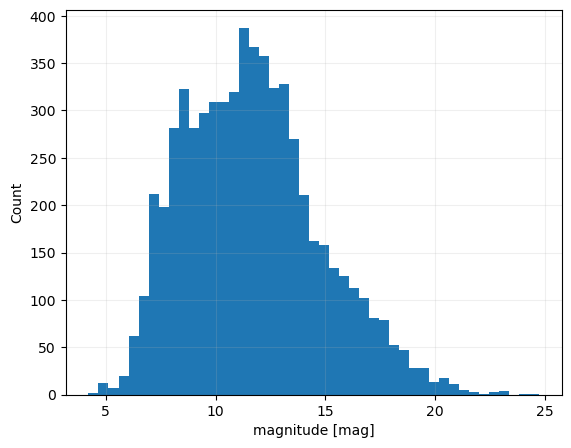

In [9]:
plt.figure(figsize=(6.4, 5))
_ = plt.hist(streak_table_masked['mag_zen'], bins="auto")
plt.xlabel("magnitude [mag]")
plt.ylabel("Count")
# plt.title("Streak brightness distribution")
plt.grid(alpha=0.2)
plt.show()

In [18]:
print(f'Number of streaks brighter than MAG 7 : {(streak_table_masked['mag_zen'] < 7).sum()}')

Number of streaks brighter than MAG 7 : 241


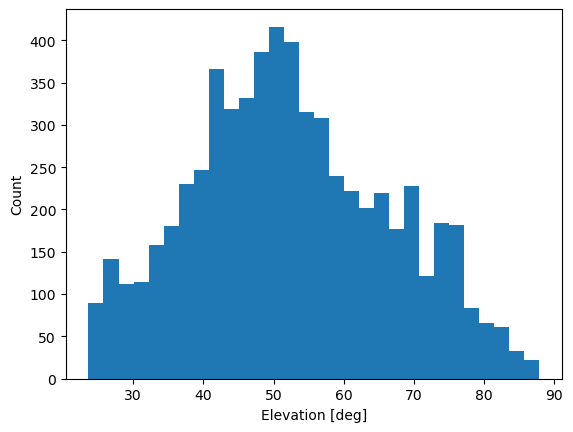

23.61749516678021


In [ ]:
_ = plt.hist(streak_table_masked['al'], bins="auto")
plt.xlabel("Elevation [deg]")
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.show()

print(f"{streak_table_masked['al'].min()}")

In [20]:
np.unique(streak_table_masked["OBJECT_TYPE"])

DEBRIS
PAYLOAD
ROCKET BODY
UCT
UNKNOWN


**Skyplot (Starlink generation)**

UCT 4159
oneweb 68
others 1853
v1 29
v1.5 43


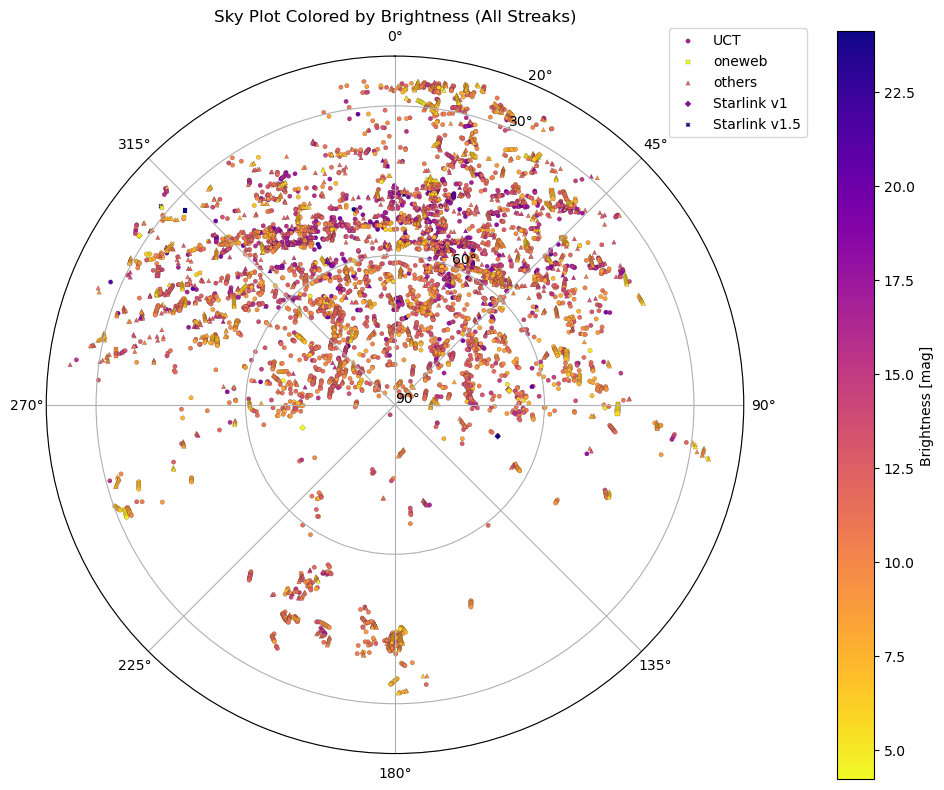

In [21]:
az = np.deg2rad(streak_table_masked["az"].data.astype(float))
alt = np.asarray(streak_table_masked["al"], dtype=float)
mag = np.asarray(streak_table_masked["mag_zen"], dtype=float)
gen = np.asarray(streak_table_masked["generation"])

r = 90 - alt

fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, polar=True)

generations = np.unique(gen)

markers = ["o", "s", "^", "D", "X"]   # 見やすい形に変更

sc_list = []

for i, g in enumerate(generations):
    mask = (gen == g)
    print(g, np.sum(mask))  # 確認用

    if g == "v1" or g == "v1.5" or g == "v2":
        generation_label = f"Starlink {g}"
    else:
        generation_label = g

    sc = ax.scatter(
        az[mask],
        r[mask],
        c=mag[mask],
        # cmap="plasma_r",
        cmap="plasma_r",
        s=10,   # 大きくする
        edgecolors="black",   # marker edge color
        linewidths=0.1,        # edge line width
        marker=markers[i % len(markers)],
        label=f"{generation_label}"
    )
    sc_list.append(sc)

ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

ax.set_ylim(0, 70)
ax.set_rgrids(
    [0, 30, 60, 70],
    labels=["90°", "60°", "30°", "20°"]
)

cbar = plt.colorbar(sc_list[0], ax=ax, pad=0.1, shrink=0.81)
cbar.set_label("Brightness [mag]")

ax.legend(loc="upper right", bbox_to_anchor=(1.1, 1.05))
ax.set_title("Sky Plot Colored by Brightness (All Streaks)")

plt.show()

**Skyplot by generations**

All 6152
Starlink v1 29
Starlink v1.5 43
OneWeb 68
Others 1853
UCT 4159


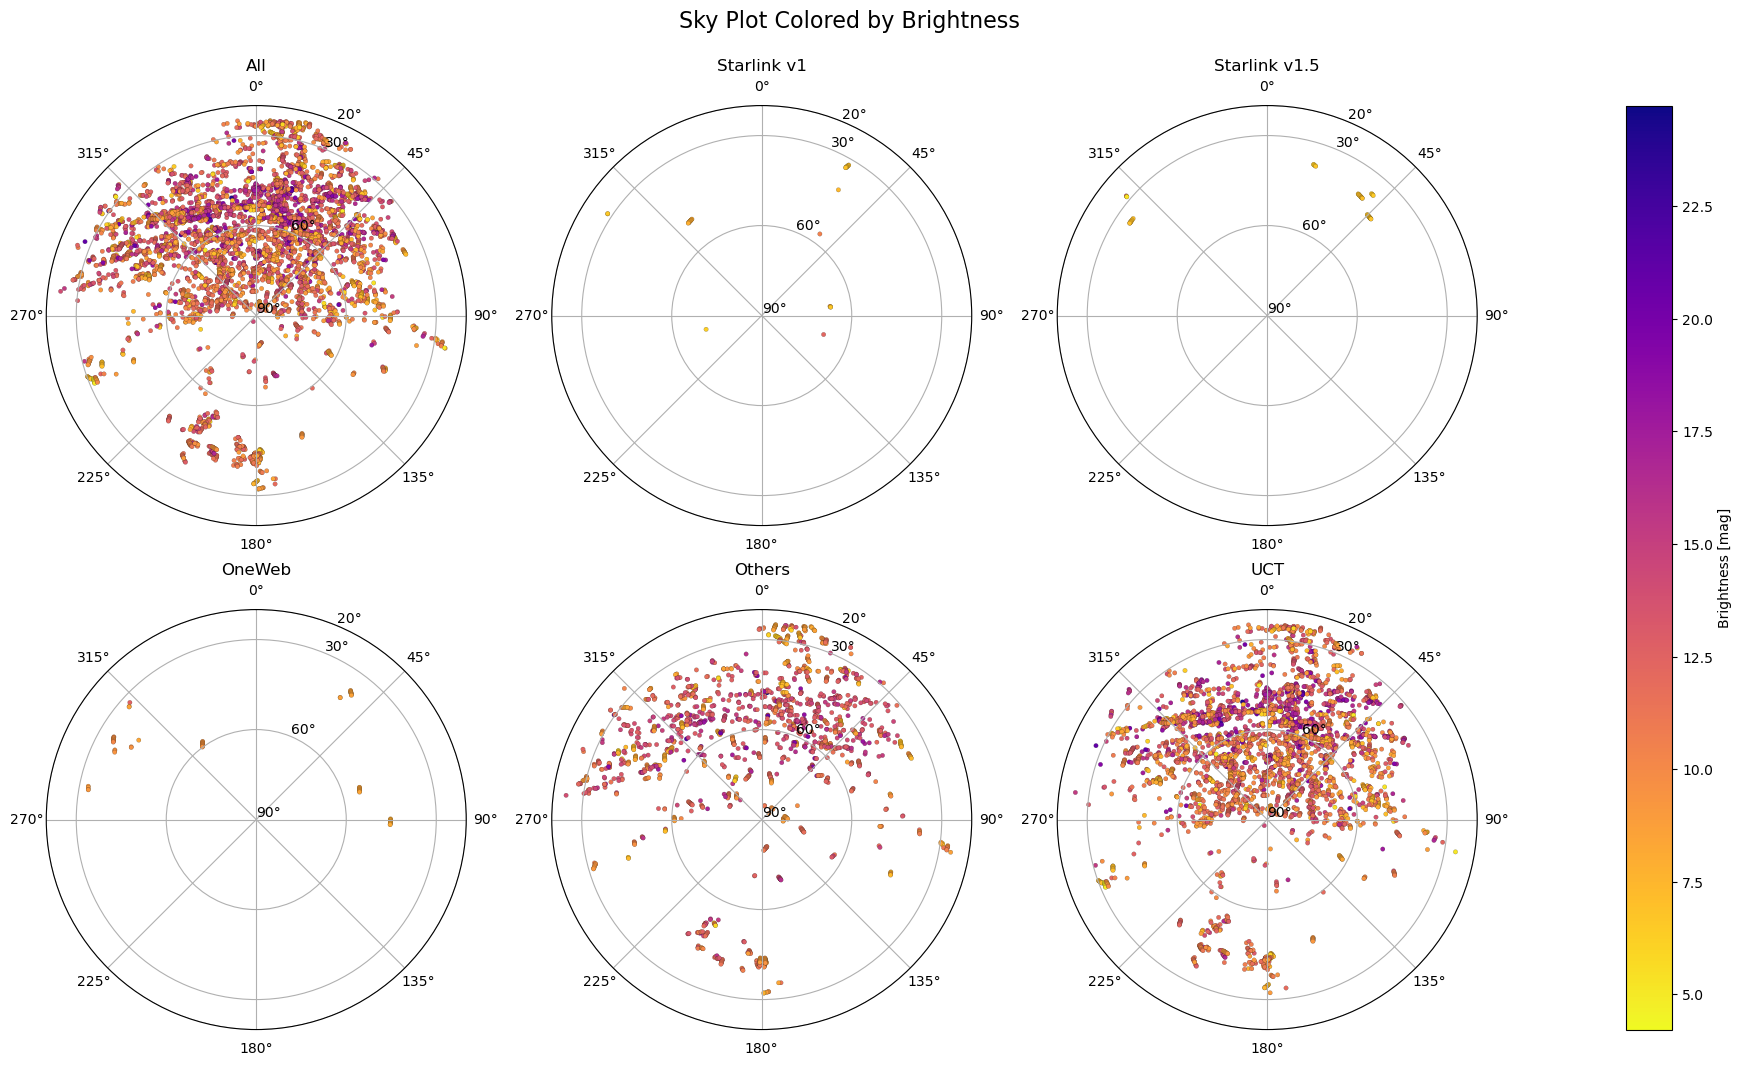

In [22]:
az = np.deg2rad(streak_table_masked["az"].data.astype(float))
alt = np.asarray(streak_table_masked["al"], dtype=float)
mag = np.asarray(streak_table_masked["mag_zen"], dtype=float)
gen = np.asarray(streak_table_masked["generation"])

r = 90 - alt

# 6枚すべてで共通のカラースケール
vmin = np.nanmin(mag)
vmax = np.nanmax(mag)

cmap = "plasma_r"
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# 表示するパネル
panels = [
    ("All", None),
    ("Starlink v1", "v1"),
    ("Starlink v1.5", "v1.5"),
    ("OneWeb", "oneweb"),
    ("Others", "others"),
    ("UCT", "UCT"),
]

fig, axes = plt.subplots(
    2, 3,
    figsize=(24, 12),
    subplot_kw={"projection": "polar"}
)

# 1行目と2行目の間隔を小さくする
fig.subplots_adjust(hspace=0.2)

axes = axes.ravel()

for ax, (title, target_gen) in zip(axes, panels):

    if target_gen is None:
        mask = np.ones(len(gen), dtype=bool)
    else:
        mask = (gen == target_gen)

    print(title, np.sum(mask))  # 確認用

    sc = ax.scatter(
        az[mask],
        r[mask],
        c=mag[mask],
        cmap=cmap,
        norm=norm,
        s=10,
        marker="o",
        edgecolors="black",   # marker edge color
        linewidths=0.1        # edge line width
    )

    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    ax.set_ylim(0, 70)

    ax.set_rgrids(
        [0, 30, 60, 70],
        labels=["90°", "60°", "30°", "20°"]
    )

    ax.set_title(title)

# 共通カラーバー用の ScalarMappable
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

# 6つのsubplot全体に対して1つのcolorbar
cbar = fig.colorbar(
    sm,
    ax=axes,
    pad=0.08,
    shrink=1
)
cbar.set_label("Brightness [mag]")

fig.suptitle(
    "Sky Plot Colored by Brightness",
    fontsize=16,
    x=0.46,
    y=0.96
)

plt.show()

Starlink v1 29 6.224361184321438 12.273423552208993
Starlink v1.5 43 5.394648526197541 14.108261590061497
OneWeb 68 7.721613105469723 12.567053043730228


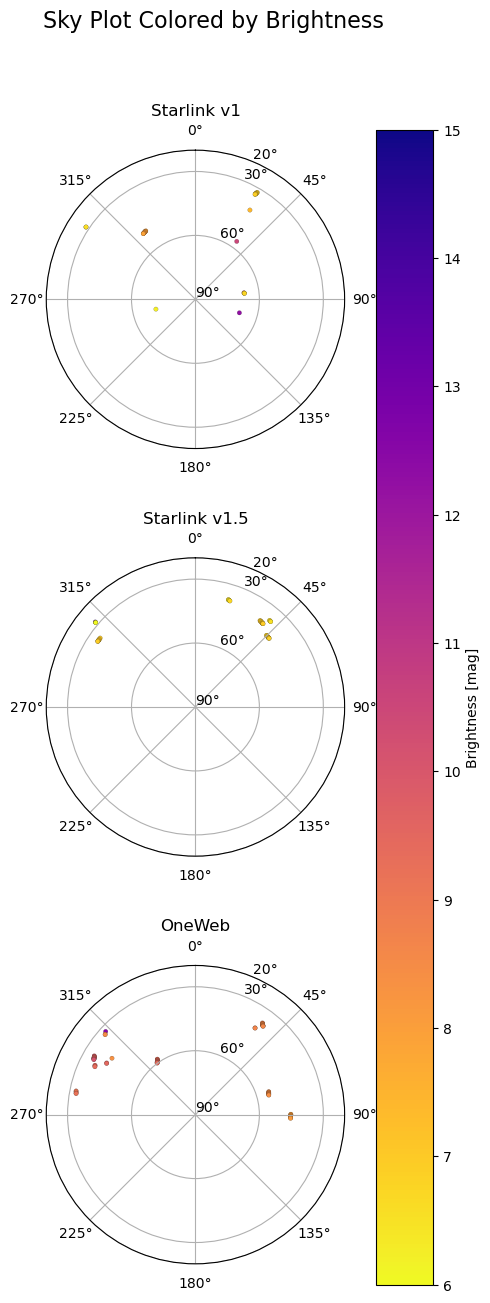

In [102]:
az = np.deg2rad(streak_table_masked["az"].data.astype(float))
alt = np.asarray(streak_table_masked["al"], dtype=float)
mag = np.asarray(streak_table_masked["mag_zen"], dtype=float)
gen = np.asarray(streak_table_masked["generation"])

r = 90 - alt

# 6枚すべてで共通のカラースケール
vmin = 6
vmax = 15

cmap = "plasma_r"
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# 表示するパネル
panels = [
    ("Starlink v1", "v1"),
    ("Starlink v1.5", "v1.5"),
    ("OneWeb", "oneweb")
]

fig, axes = plt.subplots(
    3, 1,
    figsize=(5, 15),
    subplot_kw={"projection": "polar"}
)

# 1行目と2行目の間隔を小さくする
fig.subplots_adjust(hspace=0.2)

axes = axes.ravel()

for ax, (title, target_gen) in zip(axes, panels):

    if target_gen is None:
        mask = np.ones(len(gen), dtype=bool)
    else:
        mask = (gen == target_gen)

    print(title, np.sum(mask), mag[mask].min(), mag[mask].max())  # 確認用

    sc = ax.scatter(
        az[mask],
        r[mask],
        c=mag[mask],
        cmap=cmap,
        norm=norm,
        s=10,
        marker="o",
        edgecolors="black",   # marker edge color
        linewidths=0.1        # edge line width
    )

    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    ax.set_ylim(0, 70)

    ax.set_rgrids(
        [0, 30, 60, 70],
        labels=["90°", "60°", "30°", "20°"]
    )

    ax.set_title(title)

# 共通カラーバー用の ScalarMappable
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

# 6つのsubplot全体に対して1つのcolorbar
cbar = fig.colorbar(
    sm,
    ax=axes,
    pad=0.08,
    shrink=1
)
cbar.set_label("Brightness [mag]")

fig.suptitle(
    "Sky Plot Colored by Brightness",
    fontsize=16,
    x=0.46,
    y=0.96
)

plt.show()

**Skyplot by object type**

All 6152
Payload 1396
Debris 7
Rochet Body 584
Unknown 6
No Match 4159


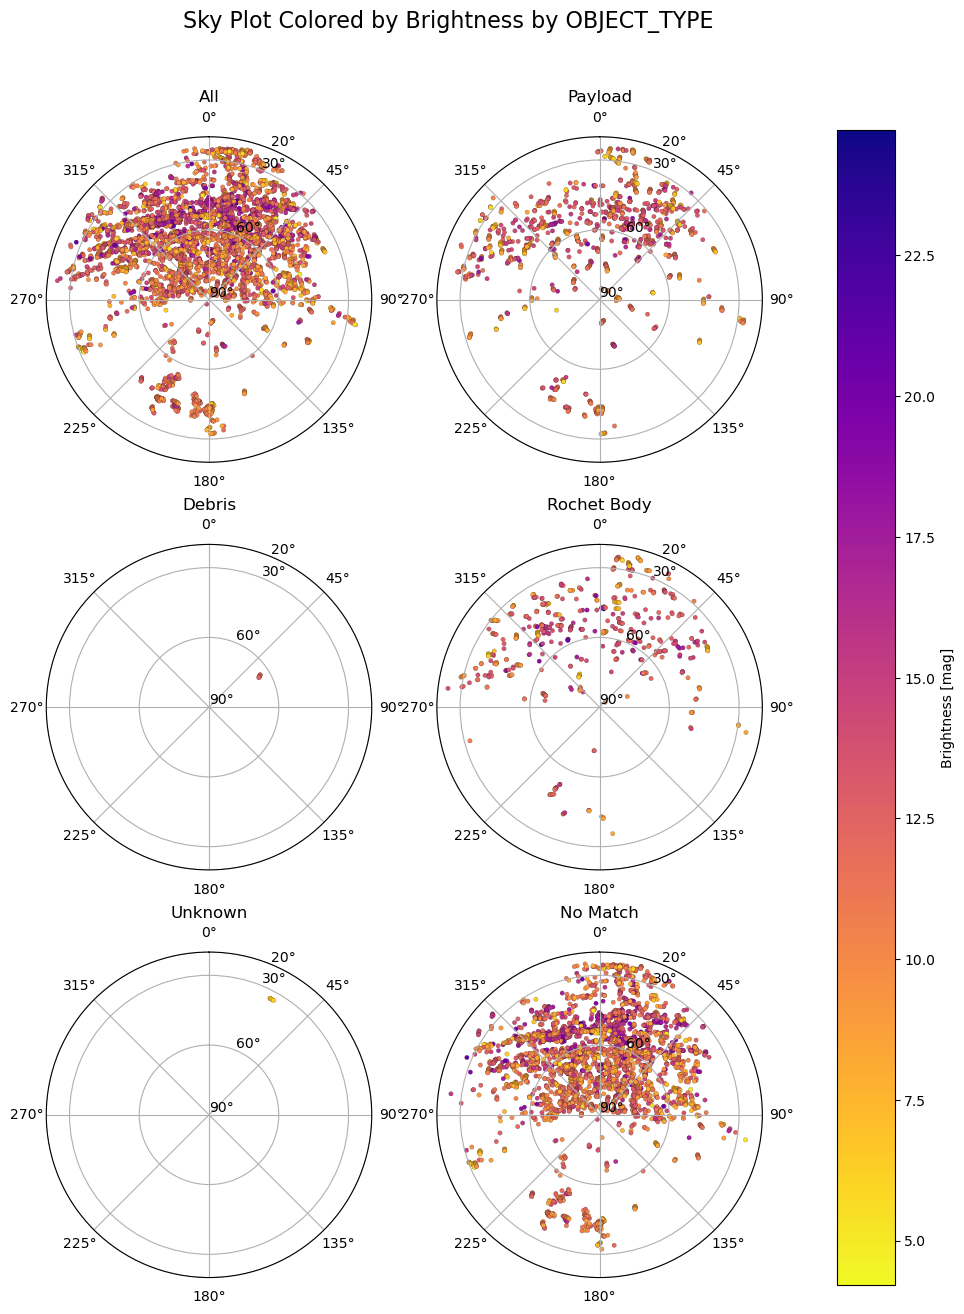

In [ ]:
az = np.deg2rad(streak_table_masked["az"].data.astype(float))
alt = np.asarray(streak_table_masked["al"], dtype=float)
mag = np.asarray(streak_table_masked["mag_zen"], dtype=float)

# OBJECT_TYPE を文字列配列として取得
obj_type = np.asarray(streak_table_masked["OBJECT_TYPE"], dtype=str)

r = 90 - alt

# 6枚すべてで共通のカラースケール
vmin = np.nanmin(mag)
vmax = np.nanmax(mag)

cmap = "plasma_r"
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# 表示するパネル
panels = [
    ("All", None),
    ("Payload", "PAYLOAD"),
    ("Debris", "DEBRIS"),
    ("Rocket Body", "ROCKET BODY"),
    ("Catalogued Unknown Type Object", "UNKNOWN"),
    ("No Match", "UCT"),
]

fig, axes = plt.subplots(
    3, 2,
    figsize=(12, 15),
    subplot_kw={"projection": "polar"}
)

# 1行目と2行目の間隔を小さくする
fig.subplots_adjust(hspace=0.2)

axes = axes.ravel()

for ax, (title, target_type) in zip(axes, panels):

    if target_type is None:
        mask = np.ones(len(obj_type), dtype=bool)
    else:
        mask = (obj_type == target_type)

    print(title, np.sum(mask))  # 確認用

    ax.scatter(
        az[mask],
        r[mask],
        c=mag[mask],
        cmap=cmap,
        norm=norm,
        s=10,
        marker="o",
        edgecolors="black",   # marker edge color
        linewidths=0.1        # edge line width
    )

    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    # altitude 20° が最も外側になるように表示範囲を設定
    # r = 90 - alt なので、alt=20° -> r=70
    ax.set_ylim(0, 70)

    ax.set_rgrids(
        [0, 30, 60, 70],
        labels=["90°", "60°", "30°", "20°"]
    )

    ax.set_title(title)

# 共通カラーバー用の ScalarMappable
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

# 6つのsubplot全体に対して1つのcolorbar
cbar = fig.colorbar(
    sm,
    ax=axes,
    pad=0.08,
    shrink=1
)
cbar.set_label("Brightness [mag]")

fig.suptitle(
    "Sky Plot Colored by Brightness by OBJECT_TYPE",
    fontsize=16,
    x=0.46,
    y=0.96
)

plt.show()

**Skyplot by size**

In [82]:
for row in streak_table_masked:
    if row["RCS_SIZE"] == None:
        row["RCS_SIZE"] = "UNKNOWN"
np.unique(streak_table_masked["RCS_SIZE"])

LARGE
MEDIUM
SMALL
UCT
UNKNOWN


All 6152
LARGE 1327
MEDIUM 630
SMALL 10
Unknown 26
No Match 4159


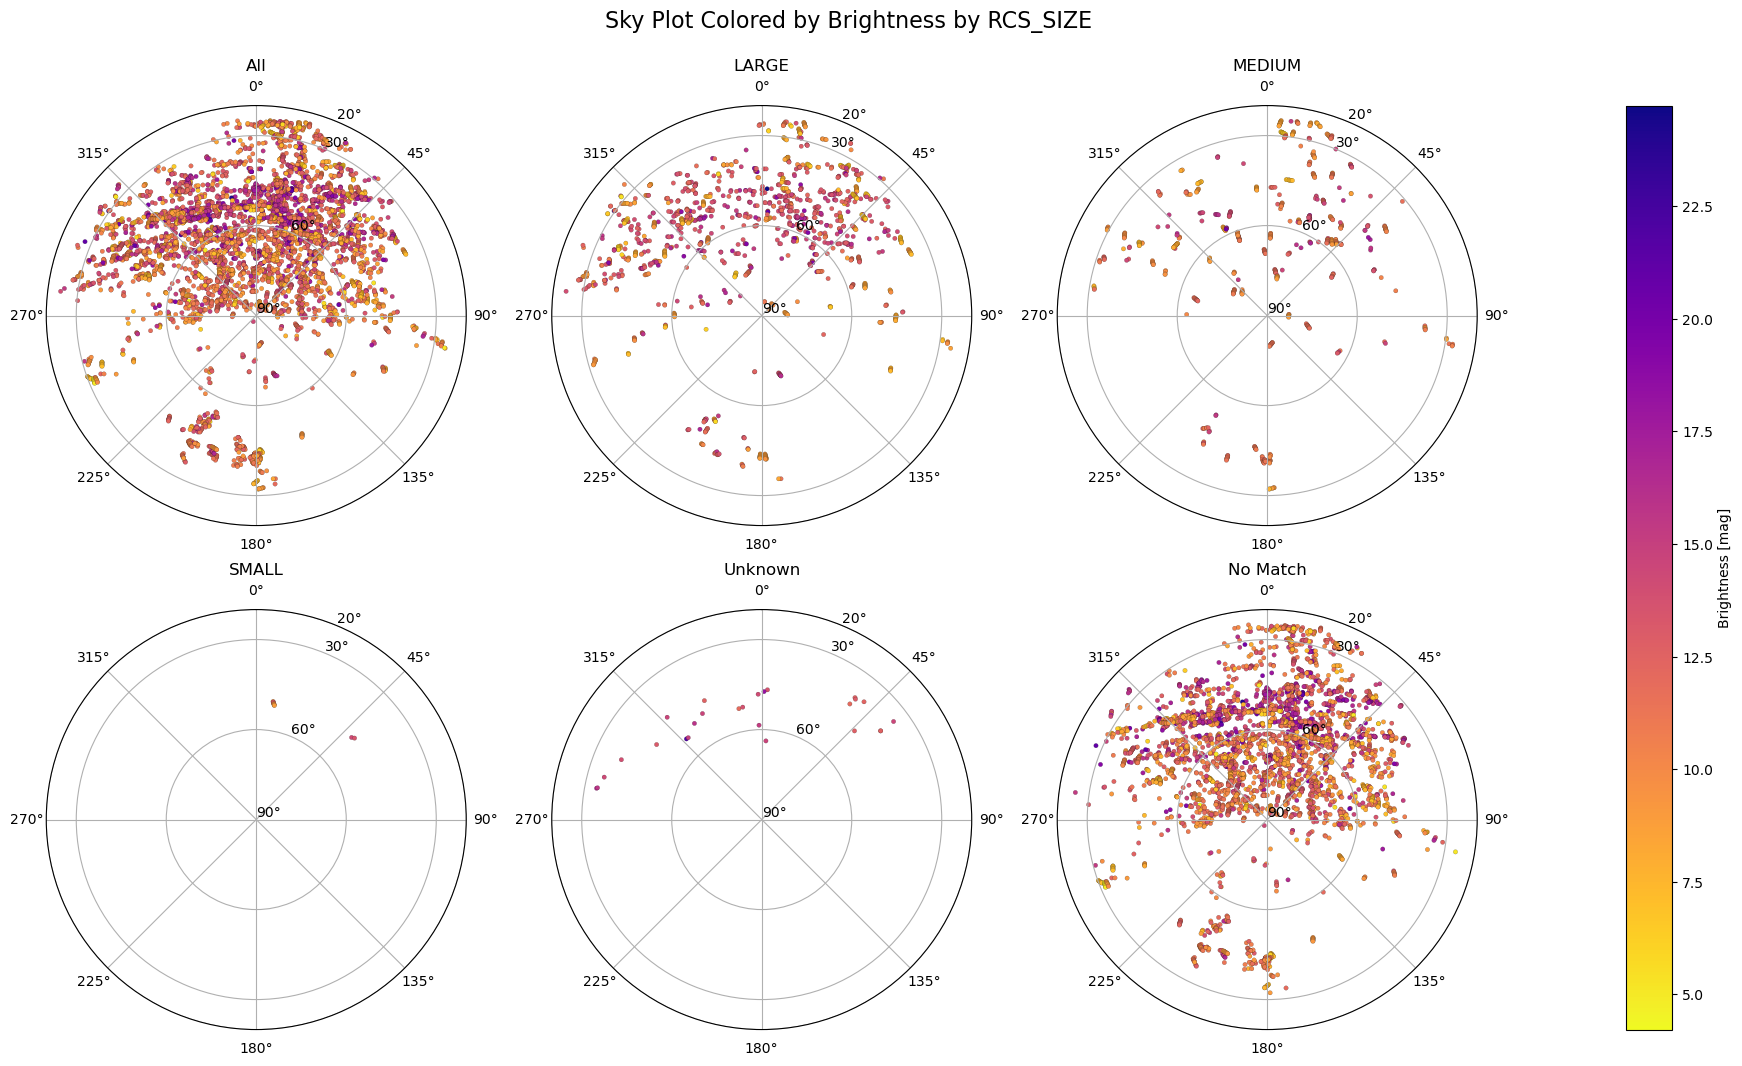

In [83]:
az = np.deg2rad(streak_table_masked["az"].data.astype(float))
alt = np.asarray(streak_table_masked["al"], dtype=float)
mag = np.asarray(streak_table_masked["mag_zen"], dtype=float)

# OBJECT_TYPE を文字列配列として取得
obj_type = np.asarray(streak_table_masked["RCS_SIZE"], dtype=str)

r = 90 - alt

# 6枚すべてで共通のカラースケール
vmin = np.nanmin(mag)
vmax = np.nanmax(mag)

cmap = "plasma_r"
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# 表示するパネル
panels = [
    ("All", None),
    ("LARGE", "LARGE"),
    ("MEDIUM", "MEDIUM"),
    ("SMALL", "SMALL"),
    ("Unknown", "UNKNOWN"),
    ("No Match", "UCT"),
]

fig, axes = plt.subplots(
    2, 3,
    figsize=(24, 12),
    subplot_kw={"projection": "polar"}
)

# 1行目と2行目の間隔を小さくする
fig.subplots_adjust(hspace=0.2)

axes = axes.ravel()

for ax, (title, target_type) in zip(axes, panels):

    if target_type is None:
        mask = np.ones(len(obj_type), dtype=bool)
    else:
        mask = (obj_type == target_type)

    print(title, np.sum(mask))  # 確認用

    ax.scatter(
        az[mask],
        r[mask],
        c=mag[mask],
        cmap=cmap,
        norm=norm,
        s=10,
        marker="o",
        edgecolors="black",   # marker edge color
        linewidths=0.1        # edge line width
    )

    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    # altitude 20° が最も外側になるように表示範囲を設定
    # r = 90 - alt なので、alt=20° -> r=70
    ax.set_ylim(0, 70)

    ax.set_rgrids(
        [0, 30, 60, 70],
        labels=["90°", "60°", "30°", "20°"]
    )

    ax.set_title(title)

# 共通カラーバー用の ScalarMappable
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

# 6つのsubplot全体に対して1つのcolorbar
cbar = fig.colorbar(
    sm,
    ax=axes,
    pad=0.08,
    shrink=1
)
cbar.set_label("Brightness [mag]")

fig.suptitle(
    "Sky Plot Colored by Brightness by RCS_SIZE",
    fontsize=16,
    x=0.46,
    y=0.96
)

plt.show()

**Skyplot by country**

CIS 914
United States 572
United Kingdom 69
JAPAN 61
China (PRC) 52
ESA 26


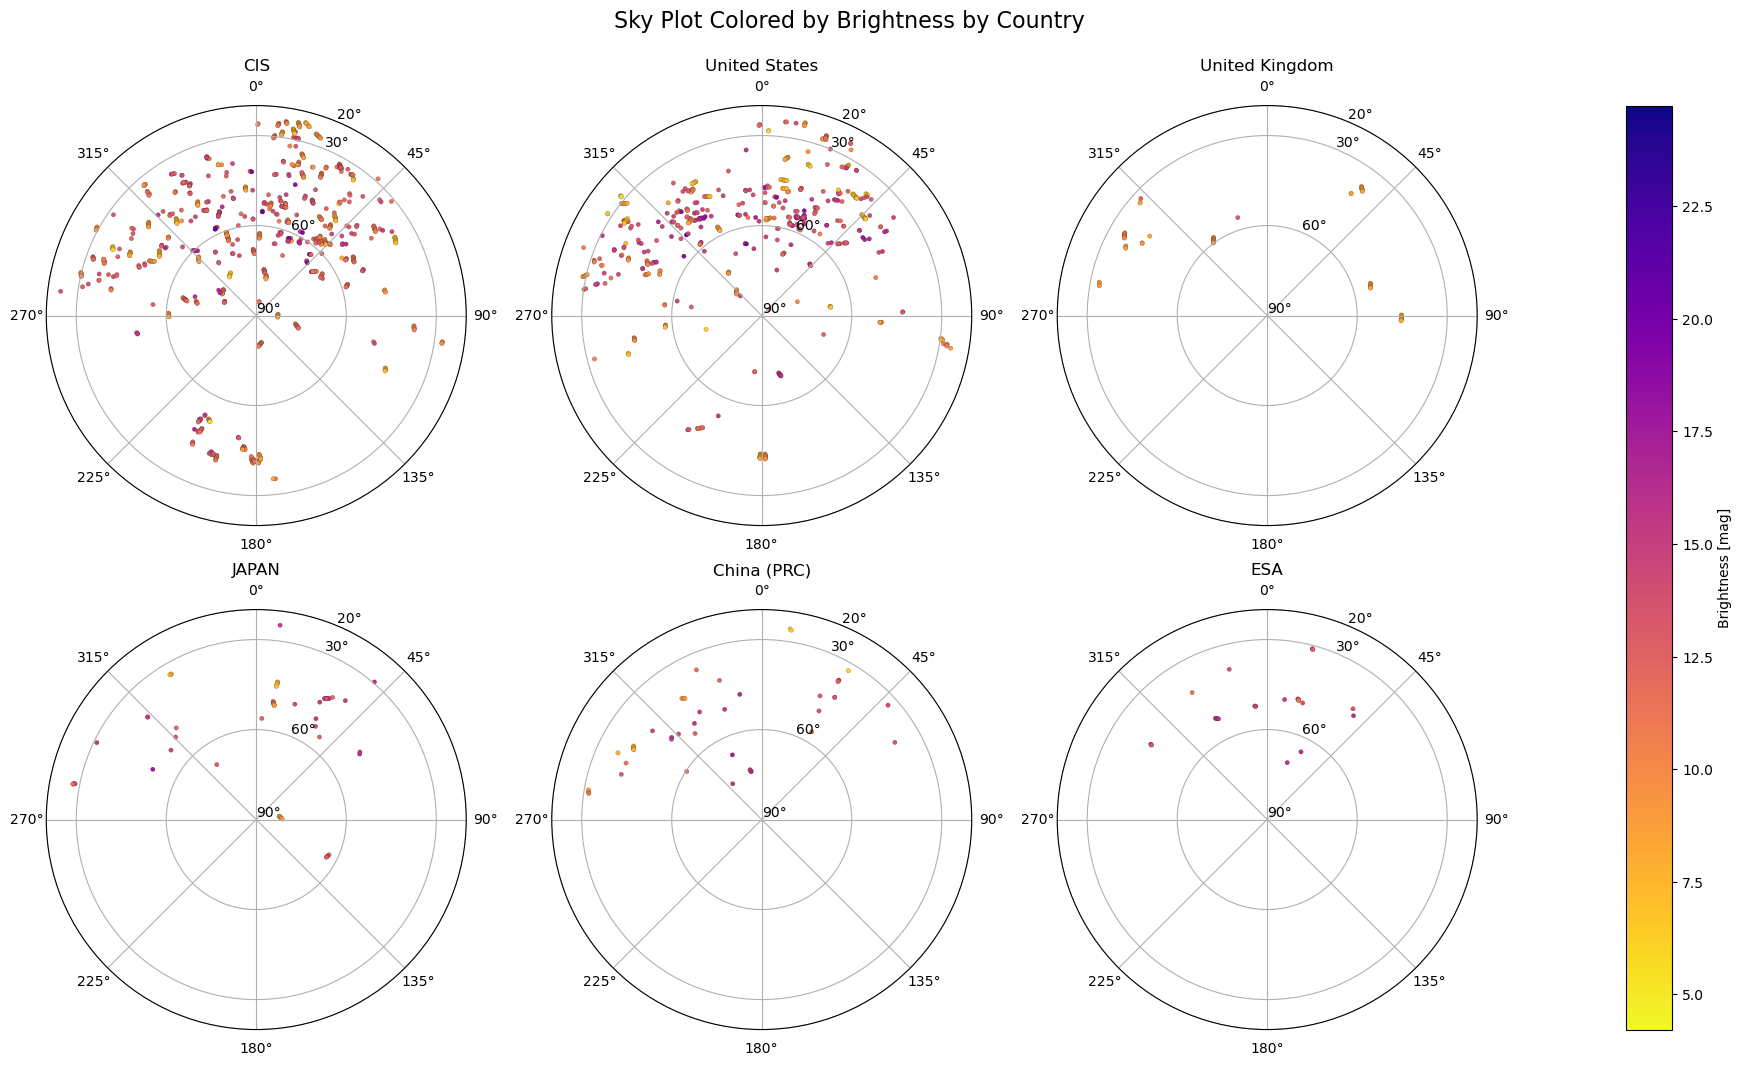

In [24]:
az = np.deg2rad(streak_table_masked["az"].data.astype(float))
alt = np.asarray(streak_table_masked["al"], dtype=float)
mag = np.asarray(streak_table_masked["mag_zen"], dtype=float)

# OBJECT_TYPE を文字列配列として取得
obj_type = np.asarray(streak_table_masked["COUNTRY"], dtype=str)

r = 90 - alt

# 6枚すべてで共通のカラースケール
vmin = np.nanmin(mag)
vmax = np.nanmax(mag)

cmap = "plasma_r"
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# 表示するパネル
panels = [
    ("CIS", "CIS"),
    ("United States", "US"),
    ("United Kingdom", "UK"),
    ("JAPAN", "JPN"),
    ("China (PRC)", "PRC"),
    ("ESA", "ESA"),
]

fig, axes = plt.subplots(
    2, 3,
    figsize=(24, 12),
    subplot_kw={"projection": "polar"}
)

# 1行目と2行目の間隔を小さくする
fig.subplots_adjust(hspace=0.2)

axes = axes.ravel()

for ax, (title, target_type) in zip(axes, panels):

    if target_type is None:
        mask = np.ones(len(obj_type), dtype=bool)
    else:
        mask = (obj_type == target_type)

    print(title, np.sum(mask))  # 確認用

    ax.scatter(
        az[mask],
        r[mask],
        c=mag[mask],
        cmap=cmap,
        norm=norm,
        s=10,
        marker="o",
        edgecolors="black",   # marker edge color
        linewidths=0.1        # edge line width
    )

    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    # altitude 20° が最も外側になるように表示範囲を設定
    # r = 90 - alt なので、alt=20° -> r=70
    ax.set_ylim(0, 70)

    ax.set_rgrids(
        [0, 30, 60, 70],
        labels=["90°", "60°", "30°", "20°"]
    )

    ax.set_title(title)

# 共通カラーバー用の ScalarMappable
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

# 6つのsubplot全体に対して1つのcolorbar
cbar = fig.colorbar(
    sm,
    ax=axes,
    pad=0.08,
    shrink=1
)
cbar.set_label("Brightness [mag]")

fig.suptitle(
    "Sky Plot Colored by Brightness by Country",
    fontsize=16,
    x=0.46,
    y=0.96
)

plt.show()

In [ ]:
countries = np.asarray([
    "UNKNOWN" if x is None or str(x).strip() == "" else str(x).strip()
    for x in streak_table_masked["COUNTRY"]
])

unique_countries, counts = np.unique(countries, return_counts=True)

order = np.argsort(counts)[::-1]

for country, count in zip(unique_countries[order], counts[order]):
    print(country, count)

**Histogram (observation time)**

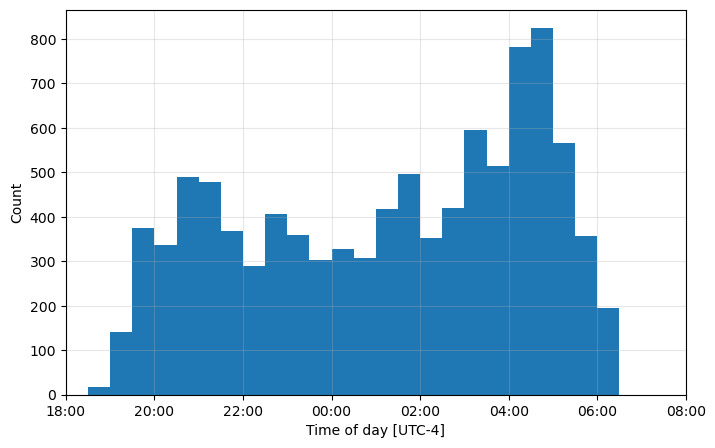

In [12]:
obs_times = Time(streak_table["dateobs_center"])

from datetime import timezone, timedelta

# UTC-4
# utc_minus4 = timezone(timedelta(hours=-(70.806389/15)))
utc_minus4 = timezone(timedelta(hours=-4))

# astropy Time → UTC-4 datetime
dt_utc = obs_times.to_datetime()
dt_local = np.array([
    t.replace(tzinfo=timezone.utc).astimezone(utc_minus4)
    for t in dt_utc
])

hours = np.array([
    t.hour + t.minute / 60 + t.second / 3600 + t.microsecond / 3600 / 1e6
    for t in dt_local
])

bins = np.arange(0, 16.0 + 0.5, 0.5)

hours_shifted = (hours - 16) % 24

mask = (hours_shifted >= 0) & (hours_shifted <= 16)
hours_plot = hours_shifted[mask]

# Plot
plt.figure(figsize=(8, 5))
plt.hist(hours_plot, bins=bins)

plt.xlabel("Time of day [UTC-4]")
plt.ylabel("Count")
# plt.title("Histogram of observation times (UTC-4)")

# Label
xticks = np.arange(0, 17, 2)
xtick_labels = [f"{int((x+16)%24):02d}:00" for x in xticks]

plt.xticks(xticks, xtick_labels)
plt.xlim(2, 16)

plt.grid(alpha=0.3)
plt.show()

### Result (Starlink)

In [ ]:
starlink_streak_table = streak_table_masked[(streak_table_masked["generation"] == "v1") | (streak_table_masked["generation"] == "v1.5")]
starlink_streak_table = starlink_streak_table.group_by("generation")

**magnitude histogram**

In [ ]:
bin_width = 0.2
bins = np.arange(2, 12 + bin_width, bin_width)

plt.xlim([2,11])

for group in starlink_streak_table.groups:
    plt.hist(group['mag_zen'], bins=bins, alpha=0.5, label="Starlink "+group[0]["generation"])

plt.xlabel("magnitude [mag]")
plt.ylabel("Count")
plt.legend()
plt.title("brightness of Starlink satellites captured by DECam")
plt.show()

**magnitude plot for each Starlinks**

In [ ]:
for group in starlink_streak_table.groups:
    plt.scatter(group["name"], group["mag_zen"], s=8, alpha=0.75, label="Starlink "+group[0]["generation"])
plt.xticks(rotation=90)
plt.legend()
plt.grid(axis='y')
plt.ylabel("magnitude [mag]")
plt.title("brightness of Starlink satellites captured by DECam")
plt.show()

**Sky plot**

In [ ]:
az = np.deg2rad(starlink_streak_table["az"].data.astype(float))
alt = np.asarray(starlink_streak_table["al"], dtype=float)
mag = np.asarray(starlink_streak_table["mag_zen"], dtype=float)
gen = np.asarray(starlink_streak_table["generation"])

r = 90 - alt

fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, polar=True)

generations = np.unique(gen)

markers = ["^", "o"]   # 見やすい形に変更

sc_list = []

for i, g in enumerate(generations):
    mask = (gen == g)
    print(g, np.sum(mask))  # 確認用

    if g == "v1" or g == "v1.5" or g == "v2":
        generation_label = f"Starlink {g}"

    sc = ax.scatter(
        az[mask],
        r[mask],
        c=mag[mask],
        # cmap="plasma_r",
        cmap="gist_rainbow",
        s=5,   # 大きくする
        marker=markers[i % len(markers)],
        label=f"{generation_label}"
    )
    sc_list.append(sc)

ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

ax.set_ylim(0, 90)
ax.set_rgrids([0, 30, 60, 90], labels=["90°", "60°", "30°", "0°"])

cbar = plt.colorbar(sc_list[0], ax=ax, pad=0.1, shrink=0.81)
cbar.set_label("Brightness [mag]")

ax.legend(loc="upper right", bbox_to_anchor=(1.1, 1.05))
ax.set_title("Sky Plot (Colored by brightness, Starlinks)")

plt.show()

### MAG < 20 Investigation
**View images**

In [ ]:
streakid_to_idx = {sid: i for i, sid in enumerate(streak_table_masked["streakID"])}
for row in streak_table_masked[(streak_table_masked["mag_zen"] > 10) & (streak_table_masked["mag_zen"] < 12)][0:100]:    
    streak_ID = row["streakID"]

    basename = path.basename(row["archive_filename"])
    md5sum = row["md5sum"]
    expnum = row["expnum"]
    ccdnum = row["ccdnum"]

    save_path = PATH_image + path.splitext(path.splitext(basename)[0])[0] + "_CCD_{0}".format(ccdnum) + path.splitext(path.splitext(basename)[0])[1] + path.splitext(basename)[1]

    plot_image_path = f"{streak_ID}_{expnum}_{str(ccdnum).zfill(2)}_gaussfit.png"

    section   = row["gauss_y"][:-2]
    amplitude = row["amplitude"][:-2]
    ground    = row["ground"][:-2]
    mu        = row["mu"][:-2]
    sigma     = row["sigma"][:-2]
    s_n       = (amplitude+ground)/ground

    mu_initial_mask = (mu > 50) & (mu < 150) & (sigma > 0)
    # mu_initial_mask[-1] = False

    ground_mask = mu_initial_mask
    for i in range(0,1):
        _,low,high = sigmaclip(ground[ground_mask],3,3)
        ground_mask = (ground > low) & (ground < high)
    
    s_n_mask = mu_initial_mask & (s_n > 1)
    for i in range(0,1):
        _,low,high = sigmaclip(s_n[s_n_mask],3,3)
        s_n_mask = (s_n > low) & (s_n < high) & (s_n > 1)
    
    for i in range(0,1):
        _,low,high = sigmaclip(mu[mu_initial_mask],2,2)
        mu_mask = (mu > low) & (mu < high)
    
    sigma_mask = mu_initial_mask
    for i in range(0,1):
        _,low,high = sigmaclip(sigma[mu_initial_mask],3,3)
        sigma_mask = (sigma > low) & (sigma < high)
    
    mask = ground_mask & s_n_mask & mu_mask & sigma_mask & mu_initial_mask

    # Debug purpose
    # Read Image file
    hdu = fits.open(save_path)
    main_header = hdu[0].header
    ccd_header = hdu[1].header
    ccd_data = hdu[1].data
    ccd_wcs = WCS(ccd_header)

    ccd_data = fits.getdata(save_path,1)
    rotated_img = sp.imgrotation.rotate_image(ccd_data, row["rt_angle"], row["initial_streak_coord"], True, 100)

    # plot (test purpose)
    y_pix = section + 25

    fig, ax = plt.subplots(
        4, 1,
        figsize=(8, 7),
        sharex=True,
        gridspec_kw={"hspace": 0.05}
    )

    # amplitude & background
    # ax[0].scatter(y_pix, amplitude+ground, s=12, label="amplitude+bkg")
    # ax[0].scatter(y_pix, ground, s=12, label="bkg")
    ax[0].scatter(y_pix, (amplitude+ground), s=8, marker='+', label="amplitude+bkg (not masked)")
    ax[0].scatter(y_pix, ground, s=8, marker='+', label="bkg (not masked)")
    ax[0].set_ylabel("count [HDU]")
    ax[0].legend()
    ax[0].grid()

    # S/N
    ax[1].scatter(y_pix, s_n, s=12)
    ax[1].scatter(y_pix[mask], s_n[mask], s=8, marker='x', color="red", label="not masked")
    ax[1].set_ylabel("s/n ratio")
    ax[1].grid()
    ax[1].legend()

    # mu ± 3σ
    ax[2].errorbar(
        y_pix[sigma>0],
        mu[sigma>0],
        yerr=3*np.array(sigma[sigma>0]),
        fmt='o',
        markersize=4,
        capsize=3,
        elinewidth=1,
        label=r"$\mu \pm 3\sigma$"
    )
    ax[2].scatter(y_pix[mask], mu[mask], s=20, marker='x', color="red", label="not masked")

    ax[2].set_xlabel("y [pix]")
    ax[2].set_ylabel("mu [pix]")
    ax[2].legend()
    ax[2].grid()

    ax[3].imshow(rotated_img, cmap='gray', origin='lower', vmin=np.percentile(rotated_img, 5), vmax=np.percentile(rotated_img, 95))

    # fig.savefig(PATH_output + "plot/mag20check/" + plot_image_path)
    # plt.close()
    plt.show()

**Compare good samples and bad samples**

In [ ]:
streak_table_masked = streak_table[(streak_table["mag_arcsec"] != None) & (streak_table["magzero"] != None)]
streak_table_bad = streak_table_masked[streak_table_masked["mag_zen"] > 20]
streak_table_good = streak_table_masked[(streak_table_masked["mag_zen"] > 10) & (streak_table_masked["mag_zen"] < 12)]

In [ ]:
streak_table_masked = streak_table[
    (streak_table["mag_arcsec"] != None) &
    (streak_table["magzero"] != None)
]

# 5 categories
categories = [
    (streak_table_masked["mag_zen"] < 5, "mag < 5"),
    ((streak_table_masked["mag_zen"] >= 5) & (streak_table_masked["mag_zen"] < 10), "5 <= mag < 10"),
    ((streak_table_masked["mag_zen"] >= 10) & (streak_table_masked["mag_zen"] < 15), "10 <= mag < 15"),
    ((streak_table_masked["mag_zen"] >= 15) & (streak_table_masked["mag_zen"] < 20), "15 <= mag < 20"),
    (streak_table_masked["mag_zen"] >= 20, "20 <= mag"),
]

In [ ]:
# 全カテゴリーの amplitude_mean をまとめて共通binを作成
all_data = np.concatenate([
    np.asarray(streak_table_masked["amplitude_mean"][mask], dtype=float)
    for mask, label in categories
    if np.sum(mask) > 0
])

bins = np.histogram_bin_edges(all_data, bins="auto")

# plot
plt.figure()

for mask, label in categories:
    data = np.asarray(streak_table_masked["amplitude_mean"][mask], dtype=float)

    if len(data) == 0:
        continue

    plt.hist(
        data,
        bins=bins,
        alpha=0.5,
        label=f"{label} (N={len(data)})"
    )

plt.xlabel("A")
plt.ylabel("N")
plt.legend()
plt.show()

In [ ]:
# 全カテゴリーの amplitude_mean をまとめて共通binを作成
all_data = np.concatenate([
    np.asarray(streak_table_masked["mu_mean"][mask], dtype=float)
    for mask, label in categories
    if np.sum(mask) > 0
])

bins = np.histogram_bin_edges(all_data, bins="auto")

# plot
plt.figure()

for mask, label in categories:
    data = np.asarray(streak_table_masked["mu_mean"][mask], dtype=float)

    if len(data) == 0:
        continue

    plt.hist(
        data,
        bins=bins,
        alpha=0.5,
        label=f"{label} (N={len(data)})"
    )

plt.xlabel("mu")
plt.ylabel("N")
plt.legend()
plt.show()

In [ ]:
# 全カテゴリーの amplitude_mean をまとめて共通binを作成
all_data = np.concatenate([
    np.asarray(streak_table_masked["mu_std"][mask], dtype=float)
    for mask, label in categories
    if np.sum(mask) > 0
])

bins = np.histogram_bin_edges(all_data, bins="auto")

# plot
plt.figure()

for mask, label in categories:
    data = np.asarray(streak_table_masked["mu_std"][mask], dtype=float)

    if len(data) == 0:
        continue

    plt.hist(
        data,
        bins=bins,
        alpha=0.5,
        label=f"{label} (N={len(data)})"
    )

plt.xlabel("std(mu)")
plt.ylabel("N")
plt.legend()
plt.show()

In [ ]:
# 全カテゴリーの amplitude_mean をまとめて共通binを作成
all_data = np.concatenate([
    np.asarray(streak_table_masked["sigma_mean"][mask], dtype=float)
    for mask, label in categories
    if np.sum(mask) > 0
])

bins = np.histogram_bin_edges(all_data, bins="auto")

# plot
plt.figure()

for mask, label in categories:
    data = np.asarray(streak_table_masked["sigma_mean"][mask], dtype=float)

    if len(data) == 0:
        continue

    plt.hist(
        data,
        bins=bins,
        alpha=0.5,
        label=f"{label} (N={len(data)})"
    )

plt.xlabel("sigma")
plt.ylabel("N")
plt.legend()
plt.show()

In [ ]:
# 全カテゴリーの amplitude_mean をまとめて共通binを作成
all_data = np.concatenate([
    np.asarray(streak_table_masked["s_n_mean"][mask], dtype=float)
    for mask, label in categories
    if np.sum(mask) > 0
])

bins = np.histogram_bin_edges(all_data, bins="auto")

# plot
plt.figure()

for mask, label in categories:
    data = np.asarray(streak_table_masked["s_n_mean"][mask], dtype=float)

    if len(data) == 0:
        continue

    plt.hist(
        data,
        bins=bins,
        alpha=0.5,
        label=f"{label} (N={len(data)})"
    )

plt.xlabel("s/n")
plt.ylabel("N")
plt.legend()
plt.show()

In [ ]:
# 全カテゴリーの amplitude_mean をまとめて共通binを作成
all_data = np.concatenate([
    np.asarray(streak_table_masked["mask_ratio"][mask], dtype=float)
    for mask, label in categories
    if np.sum(mask) > 0
])

bins = np.histogram_bin_edges(all_data, bins="auto")

# plot
plt.figure()

for mask, label in categories:
    data = np.asarray(streak_table_masked["mask_ratio"][mask], dtype=float)

    if len(data) == 0:
        continue

    plt.hist(
        data,
        bins=bins,
        alpha=0.5,
        label=f"{label} (N={len(data)})"
    )

plt.xlabel("Not masked ratio")
plt.ylabel("N")
plt.legend()
plt.show()

In [ ]:
# 全カテゴリーの amplitude_mean をまとめて共通binを作成
all_data = np.concatenate([
    np.asarray(streak_table_masked["seeing"][mask], dtype=float)
    for mask, label in categories
    if np.sum(mask) > 0
])

bins = np.histogram_bin_edges(all_data, bins="auto")

# plot
plt.figure()

for mask, label in categories:
    data = np.asarray(streak_table_masked["seeing"][mask], dtype=float)

    if len(data) == 0:
        continue

    plt.hist(
        data,
        bins=bins,
        alpha=0.5,
        label=f"{label} (N={len(data)})"
    )

plt.xlabel("seeing")
plt.ylabel("N")
plt.legend()
plt.show()

In [ ]:
# 全カテゴリーの amplitude_mean をまとめて共通binを作成
all_data = np.concatenate([
    np.asarray(streak_table_masked["airmass"][mask], dtype=float)
    for mask, label in categories
    if np.sum(mask) > 0
])

bins = np.histogram_bin_edges(all_data, bins="auto")

# plot
plt.figure()

for mask, label in categories:
    data = np.asarray(streak_table_masked["airmass"][mask], dtype=float)

    if len(data) == 0:
        continue

    plt.hist(
        data,
        bins=bins,
        alpha=0.5,
        label=f"{label} (N={len(data)})"
    )

plt.xlabel("airmass")
plt.ylabel("N")
plt.legend()
plt.show()

In [ ]:
# 全カテゴリーの amplitude_mean をまとめて共通binを作成
all_data = np.concatenate([
    np.asarray(streak_table_masked["magzero"][mask], dtype=float)
    for mask, label in categories
    if np.sum(mask) > 0
])

bins = np.histogram_bin_edges(all_data, bins="auto")

# plot
plt.figure()

for mask, label in categories:
    data = np.asarray(streak_table_masked["magzero"][mask], dtype=float)

    if len(data) == 0:
        continue

    plt.hist(
        data,
        bins=bins,
        alpha=0.5,
        label=f"{label} (N={len(data)})"
    )

plt.xlabel("magzero")
plt.ylabel("N")
plt.legend()
plt.show()

In [ ]:
all_data = np.concatenate([streak_table_bad["amplitude_mean"], streak_table_good["amplitude_mean"]])
bins = np.histogram_bin_edges(all_data, bins="auto")

plt.hist(streak_table_bad["amplitude_mean"], bins=bins, alpha=0.5, label="bad sample (20 < mag)")
plt.hist(streak_table_good["amplitude_mean"], bins=bins, alpha=0.5, label="good sample (10 < mag < 12)")

plt.xlabel("A")
plt.ylabel("N")
plt.legend()
plt.show()

In [ ]:
all_data = np.concatenate([streak_table_bad["mu_mean"], streak_table_good["mu_mean"]])
bins = np.histogram_bin_edges(all_data, bins="auto")

plt.hist(streak_table_bad["mu_mean"], bins=bins, alpha=0.5, label="bad sample (20 < mag)")
plt.hist(streak_table_good["mu_mean"], bins=bins, alpha=0.5, label="good sample (10 < mag < 12)")

plt.xlabel("mu")
plt.ylabel("N")
plt.legend()
plt.show()

In [ ]:
all_data = np.concatenate([streak_table_bad["mu_std"], streak_table_good["mu_std"]])
bins = np.histogram_bin_edges(all_data, bins="auto")

plt.hist(streak_table_bad["mu_std"], bins=bins, alpha=0.5, label="bad sample (20 < mag)")
plt.hist(streak_table_good["mu_std"], bins=bins, alpha=0.5, label="good sample (10 < mag < 12)")

plt.xlabel("std(mu)")
plt.ylabel("N")
plt.legend()
plt.show()

In [ ]:
bin_width = 0.05

all_data = np.concatenate([streak_table_bad["mu_std"], streak_table_good["mu_std"]])
bins = np.arange(all_data.min(), all_data.max() + bin_width, bin_width)

plt.hist(streak_table_bad["mu_std"], bins=bins, alpha=0.5, label="bad sample (20 < mag)")
plt.hist(streak_table_good["mu_std"], bins=bins, alpha=0.5, label="good sample (10 < mag < 12)")

plt.xlabel("std(mu)")
plt.ylabel("N")
plt.xlim(0,1)
plt.legend()
plt.show()

In [ ]:
all_data = np.concatenate([streak_table_bad["sigma_mean"], streak_table_good["sigma_mean"]])
bins = np.histogram_bin_edges(all_data, bins="auto")

plt.hist(streak_table_bad["sigma_mean"], bins=bins, alpha=0.5, label="bad sample (20 < mag)")
plt.hist(streak_table_good["sigma_mean"], bins=bins, alpha=0.5, label="good sample (10 < mag < 12)")

plt.xlabel("sigma")
plt.ylabel("N")
plt.legend()
plt.show()

In [ ]:
all_data = np.concatenate([streak_table_bad["s_n_mean"], streak_table_good["s_n_mean"]])
bins = np.histogram_bin_edges(all_data, bins="auto")

plt.hist(streak_table_bad["s_n_mean"], bins=bins, alpha=0.5, label="bad sample (20 < mag)")
plt.hist(streak_table_good["s_n_mean"], bins=bins, alpha=0.5, label="good sample (10 < mag < 12)")

plt.xlabel("s/n")
plt.ylabel("N")
plt.legend()
plt.show()

In [ ]:
all_data = np.concatenate([streak_table_bad["mask_ratio"], streak_table_good["mask_ratio"]])
bins = np.histogram_bin_edges(all_data, bins="auto")

plt.hist(streak_table_bad["mask_ratio"], bins=bins, alpha=0.5, label="bad sample (20 < mag)")
plt.hist(streak_table_good["mask_ratio"], bins=bins, alpha=0.5, label="good sample (10 < mag < 12)")

plt.xlabel("NOT masked ratio")
plt.ylabel("N")
plt.legend()
plt.show()

In [ ]:
mask_number_bad = []
mask_number_good = []

for row in streak_table_bad:
    mask_number_bad.append(int(len(row["amplitude"]) * row["mask_ratio"]))
for row in streak_table_good:
    mask_number_good.append(int(len(row["amplitude"]) * row["mask_ratio"]))

mask_number_bad = np.array(mask_number_bad)
mask_number_good = np.array(mask_number_good)
streak_table_bad["mask_number"] = mask_number_bad
streak_table_good["mask_number"] = mask_number_good

all_data = np.concatenate([streak_table_bad["mask_number"], streak_table_good["mask_number"]])
bins = np.histogram_bin_edges(all_data, bins="auto")

plt.hist(streak_table_bad["mask_number"], bins=bins, alpha=0.5, label="bad sample (20 < mag)")
plt.hist(streak_table_good["mask_number"], bins=bins, alpha=0.5, label="good sample (10 < mag < 12)")

plt.xlabel("NOT masked number")
plt.ylabel("N")
plt.legend()
plt.show()

In [ ]:
all_data = np.concatenate([streak_table_bad["seeing"], streak_table_good["seeing"]])
bins = np.histogram_bin_edges(all_data, bins="auto")

plt.hist(streak_table_bad["seeing"], bins=bins, alpha=0.5, label="bad sample (20 < mag)")
plt.hist(streak_table_good["seeing"], bins=bins, alpha=0.5, label="good sample (10 < mag < 12)")

plt.xlabel("seeing")
plt.ylabel("N")
plt.legend()
plt.show()

In [ ]:
all_data = np.concatenate([streak_table_bad["airmass"], streak_table_good["airmass"]])
bins = np.histogram_bin_edges(all_data, bins="auto")

plt.hist(streak_table_bad["airmass"], bins=bins, alpha=0.5, label="bad sample (20 < mag)")
plt.hist(streak_table_good["airmass"], bins=bins, alpha=0.5, label="good sample (10 < mag < 12)")

plt.xlabel("airmass")
plt.ylabel("N")
plt.legend()
plt.show()

In [ ]:
all_data = np.concatenate([streak_table_bad["magzero"], streak_table_good["magzero"]])
bins = np.histogram_bin_edges(all_data, bins="auto")

plt.hist(streak_table_bad["magzero"], bins=bins, alpha=0.5, label="bad sample (20 < mag)")
plt.hist(streak_table_good["magzero"], bins=bins, alpha=0.5, label="good sample (10 < mag < 12)")

plt.xlabel("magzero")
plt.ylabel("N")
plt.legend()
plt.show()